[STEP 1] Checking CSV file and loading data...
    - Loaded data shape: (205, 32) (time: 0.01s)
[STEP 2] Final feature shape: (205, 28)
    - Label distribution:
 Label
1    138
0     67
Name: count, dtype: int64
[STEP 3] Splitting into train/test sets (30% test)...
    - Train shape: (143, 28) Test shape: (62, 28) (time: 0.00s)
[STEP 4] Handling class imbalance with SMOTETomek...
    - Resampled shape: (174, 28) (time: 0.03s)
[STEP 5] Defining pipeline with RFECV...
[STEP 6] Setting up multiple estimators for RandomizedSearchCV...
[STEP 7] Running RandomizedSearchCV with n_iter = 20 and verbose=2 for progress...

Fitting 5 folds for each of 20 candidates, totalling 100 fits


c:\Users\chimpaleenantaphon\AppData\Local\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
10 fits failed out of a total of 100.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\chimpaleenantaphon\AppData\Local\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\chimpaleenantaphon\AppData\Local\anaconda3\Lib\site-packages\sklearn\base.py", line 1473, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\chimpaleenantaphon\A

[INFO] RandomizedSearchCV finished in 356.02s
[INFO] Best Parameters: {'rfecv__step': 2, 'rfecv__min_features_to_select': 10, 'rfecv__estimator__kernel': 'linear', 'rfecv__estimator__C': 10, 'rfecv__estimator': SVC(probability=True, random_state=42)}
[INFO] Best CV Score (Accuracy): 0.9711
[STEP 8] Evaluating on the test set...
    - Accuracy: 0.98, Precision: 1.00, Recall: 0.98, F1: 0.99, ROC AUC: 1.00
    - Evaluation took 0.02s

[Classification Report]
              precision  recall  f1-score  support
Failed             0.95    1.00      0.98    20.00
Passed             1.00    0.98      0.99    42.00
accuracy           0.98    0.98      0.98     0.98
macro avg          0.98    0.99      0.98    62.00
weighted avg       0.98    0.98      0.98    62.00


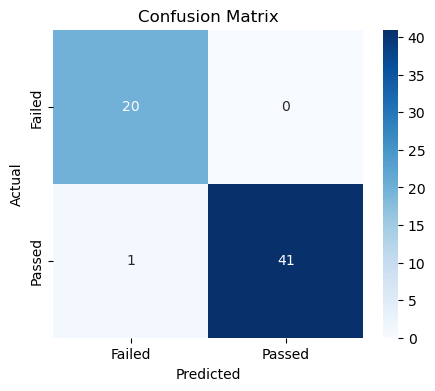

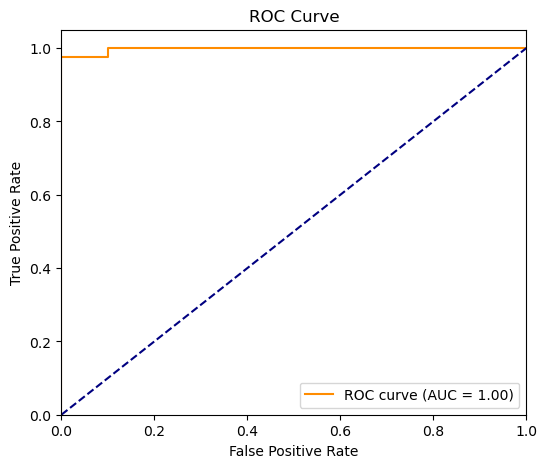

[STEP 9] Inspecting which features were selected by RFECV...
    - Number of features selected: 10
    - Selected features:
        Mean
        Shape Factor
        Skewness
        Kurtosis
        Spectral Entropy
        Spectral Flatness
        Spectral Spread
        Low Band Energy
        Mid Band Energy
        Spectral Skewness
[STEP 10] Interpreting the final chosen model...

[Interpretability] Final chosen estimator type: SVC
[SVC Interpretation] SVC does not have built-in feature importances.
Consider using SHAP (KernelExplainer) for deeper insights.

[SHAP] Generating SHAP analysis (KernelExplainer) for SVC...



  0%|          | 0/100 [00:00<?, ?it/s]

   - Creating SHAP summary plot (beeswarm)...


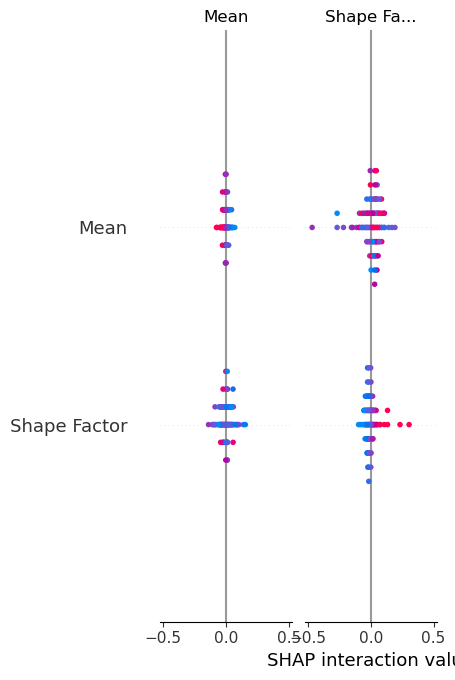


[SHAP] Feature ranking by mean(|SHAP|):


TypeError: unsupported format string passed to Index.__format__

In [4]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import logging

# Try importing shap for interpretability
try:
    import shap
except ImportError:
    shap = None
    logging.warning("SHAP not installed. SHAP-based interpretability will be skipped.")

# Sklearn / Imblearn
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc, roc_auc_score,
    accuracy_score, precision_score, recall_score, f1_score
)
from imblearn.combine import SMOTETomek

# Feature Selection & Models
from sklearn.feature_selection import RFECV
from sklearn.pipeline import Pipeline

# Candidate Estimators
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree


def interpret_model(best_pipeline, X_train, selected_feature_names):
    """
    Interpret the final fitted model from the pipeline.
    Different approaches for different estimators:
        - LogisticRegression: print coefficients, optionally shap
        - DecisionTree: visualize tree
        - RandomForest: feature_importances_, optionally shap
        - SVC: more advanced SHAP analysis (KernelExplainer)
    """
    import time
    import numpy as np
    
    from matplotlib import pyplot as plt

    # Pull out the final estimator from the pipeline's RFECV step
    rfecv_step = best_pipeline.named_steps['rfecv']
    final_estimator = rfecv_step.estimator_
    model_type = type(final_estimator).__name__
    print(f"\n[Interpretability] Final chosen estimator type: {model_type}")

    # Transform the full training data (scaler + feature selection)
    X_train_transformed = best_pipeline.transform(X_train)

    if model_type == 'LogisticRegression':
        coefs = final_estimator.coef_[0]
        sorted_idx = np.argsort(np.abs(coefs))[::-1]
        print("\nLogistic Regression Coefficients (sorted by absolute value):")
        for idx in sorted_idx:
            print(f"  {selected_feature_names[idx]:<30}  Coef: {coefs[idx]:.4f}")

        # If SHAP installed
        if shap is not None:
            print("\n[SHAP] Generating SHAP summary plot for LogisticRegression...")
            start_time = time.time()
            explainer = shap.Explainer(final_estimator, X_train_transformed)
            shap_values = explainer(X_train_transformed)
            shap.summary_plot(shap_values, X_train_transformed, feature_names=selected_feature_names)
            print(f"[SHAP] Done in {time.time() - start_time:.2f} s")

    elif model_type == 'DecisionTreeClassifier':
        from sklearn.tree import plot_tree
        max_depth = final_estimator.get_depth()
        print(f"Decision Tree Depth: {max_depth}")
        print(f"Decision Tree Number of Leaves: {final_estimator.get_n_leaves()}")

        # Visualize
        plt.figure(figsize=(12, 8))
        plot_tree(
            final_estimator,
            feature_names=selected_feature_names,
            class_names=['Failed', 'Passed'],
            filled=True,
            rounded=True
        )
        plt.title("Decision Tree Visualization")
        plt.show()

    elif model_type == 'RandomForestClassifier':
        importances = final_estimator.feature_importances_
        sorted_idx = np.argsort(importances)[::-1]
        print("\nRandom Forest Feature Importances (descending):")
        for idx in sorted_idx:
            print(f"  {selected_feature_names[idx]:<30}  Importance: {importances[idx]:.4f}")

        # If SHAP installed
        if shap is not None:
            print("\n[SHAP] Generating SHAP summary plot (TreeExplainer) for RandomForest...")
            start_time = time.time()
            explainer = shap.TreeExplainer(final_estimator)
            shap_values = explainer.shap_values(X_train_transformed)
            # For binary classification, shap_values is often a list with 2 arrays
            if isinstance(shap_values, list) and len(shap_values) > 1:
                sv = shap_values[1]
            else:
                sv = shap_values
            shap.summary_plot(sv, X_train_transformed, feature_names=selected_feature_names)
            print(f"[SHAP] Done in {time.time() - start_time:.2f} s")

    elif model_type == 'SVC':
        print("[SVC Interpretation] SVC does not have built-in feature importances.")
        print("Consider using SHAP (KernelExplainer) for deeper insights.")
        
        if shap is not None:
            # We'll do a more advanced approach here.
            print("\n[SHAP] Generating SHAP analysis (KernelExplainer) for SVC...\n")
            start_time = time.time()

            # 1) Sample the training data for speed
            sample_size = min(100, X_train_transformed.shape[0])
            X_sample = X_train_transformed[:sample_size, :]

            # 2) Create the explainer
            explainer = shap.KernelExplainer(final_estimator.predict_proba, X_sample)

            # 3) Compute SHAP values
            #   For a binary classifier, shap_values will be a list of length = n_classes (2).
            #   We'll get shap_values for the entire X_sample. 
            shap_values = explainer.shap_values(X_sample)

            # 4) Summaries
            # For binary classification in shap < 0.40, shap_values is typically [sv_class0, sv_class1].
            # We'll pick the positive class (index=1).
            if isinstance(shap_values, list) and len(shap_values) > 1:
                sv = shap_values[1]
            else:
                sv = shap_values

            print("   - Creating SHAP summary plot (beeswarm)...")
            shap.summary_plot(sv, X_sample, feature_names=selected_feature_names, plot_type='dot')

            # 5) Mean absolute shap values => top features
            mean_abs = np.mean(np.abs(sv), axis=0)
            top_indices = np.argsort(mean_abs)[::-1]
            for rank, i in enumerate(top_indices, start=1):
                print(f"{rank:2d}) {selected_feature_names[i]:<30}  Mean|SHAP|={mean_abs[i]:.4f}")
                
            # 6) (Optional) Dependence plots for top ~5 features
            top_n = 5
            print(f"\n[SHAP] Creating dependence plots for top {top_n} features...")
            for i in range(top_n):
                feat_idx = top_indices[i]
                shap.dependence_plot(
                    feat_idx,
                    sv,
                    X_sample,
                    feature_names=selected_feature_names
                )

            print(f"[SHAP] Done in {time.time() - start_time:.2f} s")

    else:
        print("[Interpretability] No specific method for this estimator.")



def train_with_rfecv(csv_path="compiled_features2.csv",
                     save_model_path="best_model_rfecv.pkl"):
    """
    1) Loads a CSV of precomputed features and 'Label'.
    2) Train-test split, then handle class imbalance with SMOTETomek.
    3) Use Pipeline: (StandardScaler) -> (RFECV) to do feature selection.
    4) RandomizedSearchCV across multiple estimators (LogisticRegression,
       RandomForest, SVC, DecisionTree) and their hyperparams.
    5) Evaluate, plot confusion matrix & ROC, save best model, and print
       which features are selected.
    6) Provide interpretability for the final chosen estimator.
    """
    overall_start = time.time()
    print("[STEP 1] Checking CSV file and loading data...")
    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"[ERROR] CSV file not found: {csv_path}")

    df_load_start = time.time()
    df = pd.read_csv(csv_path)
    print(f"    - Loaded data shape: {df.shape} (time: {time.time() - df_load_start:.2f}s)")

    if "Label" not in df.columns:
        raise ValueError("[ERROR] 'Label' column not found in the CSV.")

    drop_cols = ['Label', 'Datetime', 'Size', 'No']
    feature_cols = [c for c in df.columns if c not in drop_cols]
    X = df[feature_cols]
    y = df['Label']

    X = X.replace([np.inf, -np.inf], np.nan)
    if X.isnull().values.any():
        null_mask = X.isnull().any(axis=1)
        old_shape = X.shape
        X = X[~null_mask]
        y = y[~null_mask]
        print(f"    - Dropped {old_shape[0] - X.shape[0]} rows with NaN/inf")

    print("[STEP 2] Final feature shape:", X.shape)
    print("    - Label distribution:\n", y.value_counts())

    print("[STEP 3] Splitting into train/test sets (30% test)...")
    split_start = time.time()
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.3,
        stratify=y,
        random_state=42
    )
    print("    - Train shape:", X_train.shape, 
          "Test shape:", X_test.shape, 
          f"(time: {time.time() - split_start:.2f}s)")

    print("[STEP 4] Handling class imbalance with SMOTETomek...")
    smt_start = time.time()
    smt = SMOTETomek(random_state=42)
    X_train_res, y_train_res = smt.fit_resample(X_train, y_train)
    print("    - Resampled shape:", X_train_res.shape,
          f"(time: {time.time() - smt_start:.2f}s)")

    print("[STEP 5] Defining pipeline with RFECV...")
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('rfecv', RFECV(
            estimator=LogisticRegression(random_state=42),  # placeholder
            step=1,
            cv=5,
            scoring='accuracy',
            min_features_to_select=1
        ))
    ])

    print("[STEP 6] Setting up multiple estimators for RandomizedSearchCV...")
    param_dist = [
        # 1) Logistic Regression
        {
            'rfecv__estimator': [LogisticRegression(random_state=42, max_iter=2000)],
            'rfecv__estimator__C': [0.001, 0.01, 0.1, 1, 10],
            'rfecv__step': [1, 2],
            'rfecv__min_features_to_select': [1, 5, 10]
        },
        # 2) Random Forest
        {
            'rfecv__estimator': [RandomForestClassifier(random_state=42)],
            'rfecv__estimator__n_estimators': [50, 100, 200],
            'rfecv__estimator__max_depth': [None, 5, 10],
            'rfecv__step': [1, 2],
            'rfecv__min_features_to_select': [1, 5, 10]
        },
        # 3) SVC
        {
            'rfecv__estimator': [SVC(probability=True, random_state=42)],
            'rfecv__estimator__C': [0.01, 0.1, 1, 10],
            'rfecv__estimator__kernel': ['linear', 'rbf'],
            'rfecv__step': [1, 2],
            'rfecv__min_features_to_select': [1, 5, 10]
        },
        # 4) Decision Tree
        {
            'rfecv__estimator': [DecisionTreeClassifier(random_state=42)],
            'rfecv__estimator__max_depth': [2, 3, 5, 10],
            'rfecv__estimator__min_samples_split': [2, 5],
            'rfecv__step': [1, 2],
            'rfecv__min_features_to_select': [1, 5, 10]
        }
    ]
    n_iter_search = 20
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    print("[STEP 7] Running RandomizedSearchCV with n_iter =", n_iter_search,
          "and verbose=2 for progress...\n")
    search_start = time.time()
    rand_search = RandomizedSearchCV(
        pipeline,
        param_distributions=param_dist,
        cv=cv,
        scoring='accuracy',
        n_iter=n_iter_search,
        n_jobs=-1,
        verbose=2,            # Higher verbosity for progress info
        random_state=42,
        refit=True
    )
    rand_search.fit(X_train_res, y_train_res)
    print(f"[INFO] RandomizedSearchCV finished in {time.time() - search_start:.2f}s")

    best_model = rand_search.best_estimator_
    print("[INFO] Best Parameters:", rand_search.best_params_)
    print("[INFO] Best CV Score (Accuracy):", f"{rand_search.best_score_:.4f}")

    print("[STEP 8] Evaluating on the test set...")
    eval_start = time.time()
    y_pred = best_model.predict(X_test)

    if hasattr(best_model, "predict_proba"):
        y_proba = best_model.predict_proba(X_test)[:, 1]
    else:
        y_proba = y_pred.astype(float)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, pos_label=1)
    rec = recall_score(y_test, y_pred, pos_label=1)
    f1 = f1_score(y_test, y_pred, pos_label=1)
    roc_auc = roc_auc_score(y_test, y_proba)

    print(f"    - Accuracy: {acc:.2f}, Precision: {prec:.2f}, Recall: {rec:.2f}, "
          f"F1: {f1:.2f}, ROC AUC: {roc_auc:.2f}")
    print(f"    - Evaluation took {time.time() - eval_start:.2f}s")

    report_dict = classification_report(y_test, y_pred, 
                                        target_names=['Failed','Passed'],
                                        output_dict=True)
    report_df = pd.DataFrame(report_dict).transpose()
    print("\n[Classification Report]")
    print(report_df[['precision', 'recall', 'f1-score', 'support']].round(2))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Failed','Passed'],
                yticklabels=['Failed','Passed'])
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc(fpr, tpr):.2f})', color='darkorange')
    plt.plot([0,1],[0,1], linestyle='--', color='navy')
    plt.xlim([0,1])
    plt.ylim([0,1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc='lower right')
    plt.show()

    print("[STEP 9] Inspecting which features were selected by RFECV...")
    rfecv_step = best_model.named_steps['rfecv']
    feature_mask = rfecv_step.support_
    selected_features = list(X_train.columns[feature_mask])
    print("    - Number of features selected:", sum(feature_mask))
    print("    - Selected features:")
    for feat in selected_features:
        print("       ", feat)

    print("[STEP 10] Interpreting the final chosen model...")
    interpret_model(best_model, X_train, selected_features)

    print("[STEP 11] Saving the best model pipeline...")
    joblib.dump(best_model, save_model_path)
    print(f"    - Model saved to '{save_model_path}'")

    total_time = time.time() - overall_start
    print(f"\n[ALL DONE] Total pipeline runtime: {total_time:.2f}s\n")

    return best_model

if __name__ == "__main__":
    best_model = train_with_rfecv(
        csv_path=r"C:\Users\chimpaleenantaphon\Documents\datafortraining - Copy\compiled_features2.csv",
        save_model_path="best_model_rfecv3.pkl"
    )


[INFO] Loading the trained pipeline...
[INFO] Loaded data shape: (205, 32)
[INFO] Final shape after cleaning: (205, 28)
[INFO] Final estimator type: SVC
[INFO] Computing SHAP values (this can take time for large data or SVCs)...
[INFO] Plotting SHAP summary (beeswarm) for the sample data...


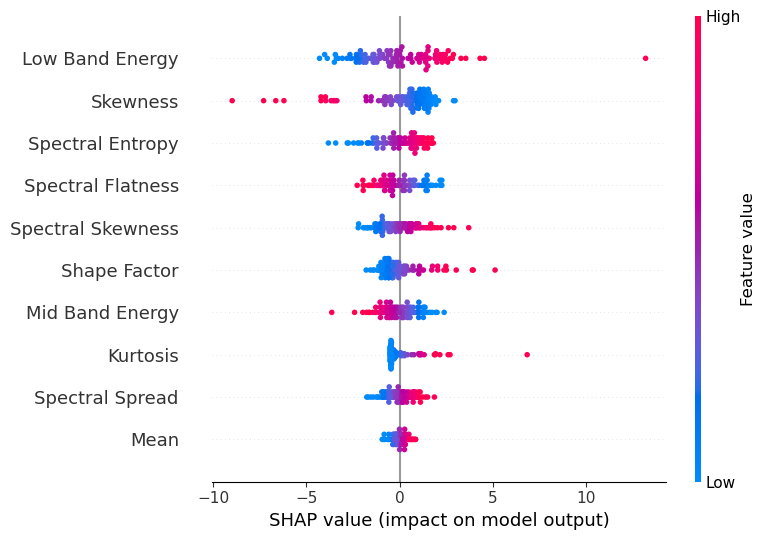


[SHAP] Top features by mean(|SHAP|):
 1) Low Band Energy                 Mean|SHAP|=1.7994
 2) Skewness                        Mean|SHAP|=1.4957
 3) Spectral Entropy                Mean|SHAP|=0.9739
 4) Spectral Flatness               Mean|SHAP|=0.9535
 5) Spectral Skewness               Mean|SHAP|=0.9223
 6) Shape Factor                    Mean|SHAP|=0.8421
 7) Mid Band Energy                 Mean|SHAP|=0.8034
 8) Kurtosis                        Mean|SHAP|=0.6011
 9) Spectral Spread                 Mean|SHAP|=0.5928
 10) Mean                            Mean|SHAP|=0.2933

[SHAP] Creating dependence plots for top 5 features...


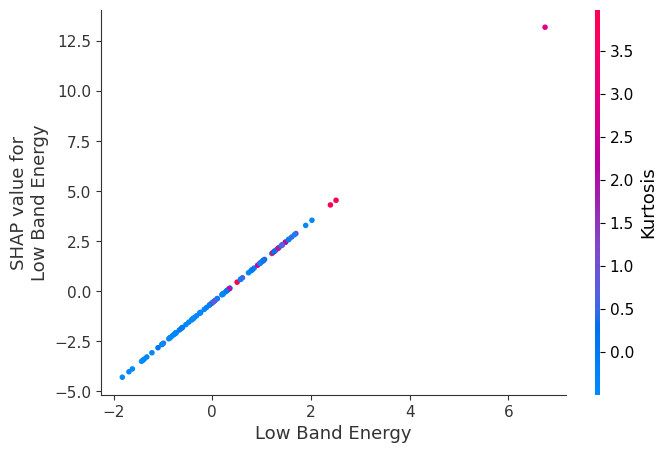

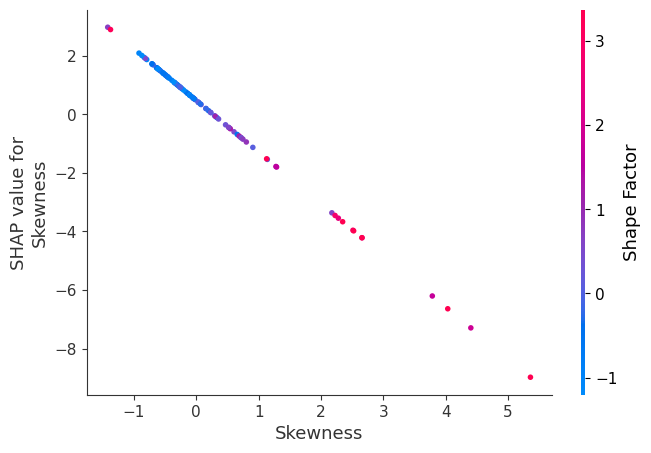

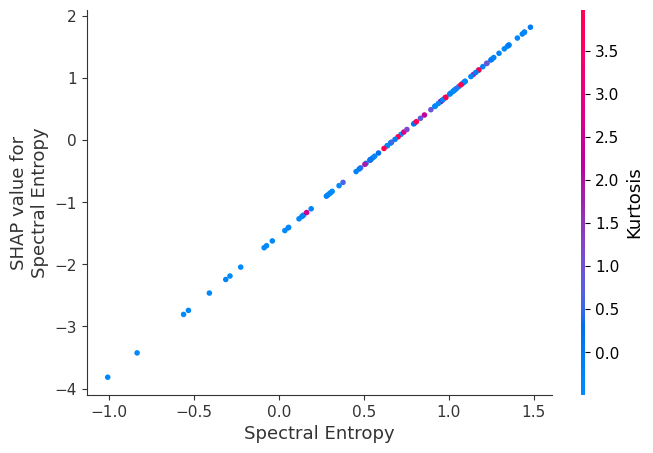

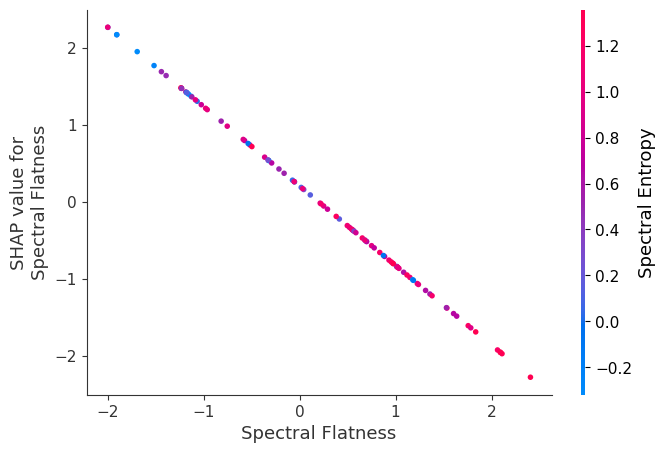

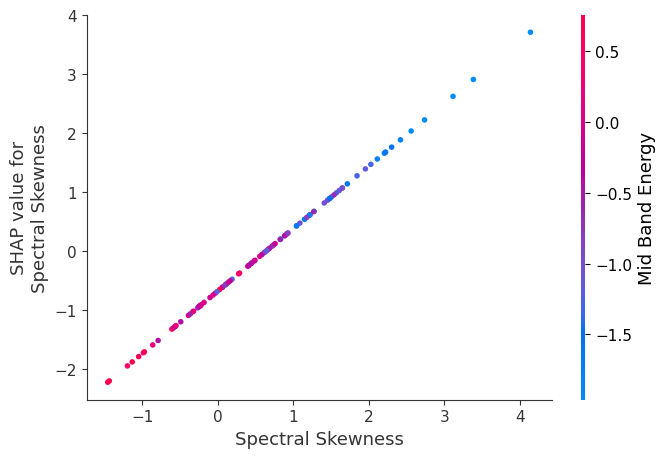


[INFO] SHAP analysis complete!


In [6]:
import joblib
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt

def run_shap_on_loaded_model(
    model_path="best_model_rfecv3.pkl",
    data_csv="compiled_features2.csv",
    sample_size=50
):
    """
    1) Load the trained pipeline from model_path.
    2) Load a CSV of data (same columns as original).
    3) Transform the data using the pipeline (up to & including feature selection).
    4) Extract the final estimator from pipeline's RFECV step.
    5) Run SHAP analysis (summary plot, feature importances, etc.).
    """

    print("[INFO] Loading the trained pipeline...")
    pipeline = joblib.load(model_path)

    # The pipeline includes:
    #   pipeline.named_steps['scaler']  -> StandardScaler
    #   pipeline.named_steps['rfecv']   -> RFECV(...) with a final_estimator

    # 1) Load your data
    df = pd.read_csv(data_csv)
    print(f"[INFO] Loaded data shape: {df.shape}")

    # In your training, you dropped columns: ['Label', 'Datetime', 'Size', 'No']
    # so do the same or adapt for new data
    drop_cols = ['Label', 'Datetime', 'Size', 'No']
    feature_cols = [c for c in df.columns if c not in drop_cols]
    
    # We'll just ignore any missing columns or do a quick check
    X = df[feature_cols].copy()
    X = X.replace([np.inf, -np.inf], np.nan).dropna(axis=0)
    
    print(f"[INFO] Final shape after cleaning: {X.shape}")

    # 2) Transform the data using the pipeline
    #    This will apply the scaler + the RFECV feature selection 
    X_transformed = pipeline.transform(X)  # transforms up to final estimator input

    # 3) Extract the final estimator from the pipeline’s RFECV step
    rfecv_step = pipeline.named_steps['rfecv']
    final_estimator = rfecv_step.estimator_  # The fully fitted estimator
    model_type = type(final_estimator).__name__
    print(f"[INFO] Final estimator type: {model_type}")

    # 4) SHAP depends on which model you have
    #    If you have SVC with probability=True -> KernelExplainer
    #    If it's a tree model (RandomForest, XGBoost), we can use TreeExplainer

    # We'll do a general approach:
    #   For large data, we sample to 'sample_size' rows for speed
    if X_transformed.shape[0] > sample_size:
        X_sample = X_transformed[:sample_size, :]
    else:
        X_sample = X_transformed

    # 5) Create your Explainer
    #    We'll do a "generic" approach: shap.Explainer tries to auto-detect
    explainer = shap.Explainer(final_estimator, X_sample)

    # 6) Compute SHAP values
    print("[INFO] Computing SHAP values (this can take time for large data or SVCs)...")
    shap_values = explainer(X_sample)

    # 7) Create a summary plot
    #    We need the names of the features that survived RFECV.
    #    'rfecv.support_' is a boolean mask of which features were selected.
    selected_mask = rfecv_step.support_
    # original feature columns
    original_feat_names = list(X.columns)  # might differ if you had more

    # We only keep the features that survived:
    selected_feat_names = [original_feat_names[i] for i, sel in enumerate(selected_mask) if sel]

    # shap_values shape for classification can be [n_samples, n_features]
    # or a list if multiple classes. Typically for binary classification, shap_values
    # might be a list: [array_class0, array_class1].
    # We'll handle that gracefully:
    if isinstance(shap_values.values, list) and len(shap_values.values) > 1:
        # e.g., shap_values.values = [class0_values, class1_values]
        sv = shap_values.values[1]  # positive class
    else:
        sv = shap_values.values

    print("[INFO] Plotting SHAP summary (beeswarm) for the sample data...")
    shap.summary_plot(sv, X_sample, feature_names=selected_feat_names, plot_type='dot')

    # 8) (Optional) Print ranking by mean absolute SHAP
    mean_abs = np.mean(np.abs(sv), axis=0)
    sorted_idx = np.argsort(mean_abs)[::-1]
    print("\n[SHAP] Top features by mean(|SHAP|):")
    for rank, i in enumerate(sorted_idx, start=1):
        print(f" {rank}) {selected_feat_names[i]:<30}  Mean|SHAP|={mean_abs[i]:.4f}")

    # 9) (Optional) Show dependence plots for top N features
    top_n = min(5, len(selected_feat_names))
    print(f"\n[SHAP] Creating dependence plots for top {top_n} features...")
    for i in range(top_n):
        feat_idx = sorted_idx[i]
        shap.dependence_plot(feat_idx, sv, X_sample, feature_names=selected_feat_names)

    print("\n[INFO] SHAP analysis complete!")


if __name__ == "__main__":
    # Example usage
    # Suppose you want to do SHAP on the same CSV you trained on
    # (or a new CSV with the same columns).
    run_shap_on_loaded_model(
        model_path="best_model_rfecv2.pkl",
        data_csv=r"C:\Users\chimpaleenantaphon\Documents\datafortraining - Copy\compiled_features2.csv",
        sample_size=100
    )
